In this notebook, we attempt to model "award-worthiness" using linear, ridge, and lasso regression

In [1]:
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

In [2]:
shortlists = pd.read_csv("../data/train_novels.csv")
shortlists.head()

,author_qid,pubDate,goodreads_id,title,authorLabel,work_qid,year,n_nom,n_win,awards_as_of_year,age,birth_country,gender,topicality,max,count,median
0,Q1006918,1965-01-01T00:00:00Z,NaN,The Ship That Sailed the Time Stream,G. C. Edmondson,Q122452512,1966,1,0,0,44.0,United States,male,0.219992,NaN,NaN,NaN
1,Q1029497,2006-11-28T00:00:00Z,NaN,Carnival,Elizabeth Bear,Q25217435,2007,2,0,1,36.0,United States,female,0.169624,NaN,NaN,NaN
2,Q1029497,2007-08-01T00:00:00Z,NaN,Undertow,Elizabeth Bear,Q131381664,2008,1,0,4,37.0,United States,female,0.245872,NaN,NaN,NaN
3,Q1029497,2010-02-20T00:00:00Z,NaN,Chill,Elizabeth Bear,Q131382134,2011,1,0,13,40.0,United States,female,-0.195356,NaN,NaN,NaN
4,Q1029497,2011-02-22T00:00:00Z,NaN,Grail,Elizabeth Bear,Q131382162,2012,1,0,15,41.0,United States,female,0.182915,NaN,NaN,NaN


**Data preparation**

In [3]:
#preparing data 

from models.prepare import prepare_df

df_train = prepare_df(shortlists)

df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   author_qid              1457 non-null   object 
 1   goodreads_id            459 non-null    float64
 2   title                   1457 non-null   object 
 3   authorLabel             1457 non-null   object 
 4   work_qid                1457 non-null   object 
 5   year                    1457 non-null   int64  
 6   n_win                   1457 non-null   int64  
 7   topicality              1455 non-null   float64
 8   max_bestseller_rank     1457 non-null   float64
 9   months_on_bestseller    1457 non-null   float64
 10  median_bestseller_rank  1457 non-null   float64
 11  mean_age                1451 non-null   float64
 12  gender                  1457 non-null   object 
 13  birth_country           1457 non-null   object 
 14  awards_as_of_year       1457 non-null   

In [4]:
#removing the rest of the non-numerical features 

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel"]
df_train.drop(columns=safe_to_drop, inplace=True)


In [5]:

df_train.isnull().sum()

work_qid                   0
year                       0
n_win                      0
topicality                 2
max_bestseller_rank        0
months_on_bestseller       0
median_bestseller_rank     0
mean_age                   6
gender                     0
birth_country              0
awards_as_of_year          0
n_nom_all                  0
month                     25
dtype: int64

In [6]:
X_train = df_train.copy()
y_train = X_train.pop("n_win")

In [7]:
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator
from models.transformers import RowCountEncoder, impute_topicality, cohort_zscore


def build_pipeline(estimator_name: str, estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("impute_topicality", FunctionTransformer(impute_topicality)),
            (
                "encode_author_data",
                RowCountEncoder(["gender", "birth_country"], "work_qid"),
            ),
            (
                "zscore",
                FunctionTransformer(
                    cohort_zscore,
                    kw_args={"columns": ["awards_as_of_year", "topicality"]},
                ),
            ),
            (
                "drop",
                FunctionTransformer(lambda df: df.drop(columns=["work_qid", "month"])),
            ),
            ("imputer", SimpleImputer(strategy="median")),
            (
                estimator_name,
                estimator,
            ),
        ]
    ).set_output(transform="pandas")



def do_cv(model, splitter=None, params=None, return_estimator=False):
    params = params or {}
    params["groups"] = X_train["year"]
    return cross_validate(
        model,
        X_train,
        y_train,
        cv=splitter or GroupKFold(n_splits=5),
        scoring=["neg_root_mean_squared_error", "r2"],
        params=params,
        n_jobs=5,
        return_estimator=return_estimator,
    )


**Model 1: Linear regression**

Step 1: Cross-validation

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn import config_context

#setting up our model and cross-validation RMSE scores
linear_pipeline = build_pipeline("linear", LinearRegression(fit_intercept=False))


with config_context(enable_metadata_routing=True):
    cv_linear = do_cv(
        linear_pipeline,
        params={"groups": X_train["year"]},
    )

r2_linear = cv_linear['test_r2']
rmse_linear = -cv_linear['test_neg_root_mean_squared_error']

print(f"Cross-validated RMSE scores per fold: {-cv_linear['test_neg_root_mean_squared_error']}")
print(f"Mean cross-validated RMSE: {-cv_linear['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"Std Dev cross-validated RMSE: {cv_linear['test_neg_root_mean_squared_error'].std():.4f}")

print(f"Cross-validated R² scores per fold: {cv_linear['test_r2']}")
print(f"Mean cross-validated R²: {cv_linear['test_r2'].mean():.4f}")
print(f"Std Dev cross-validated R²: {cv_linear['test_r2'].std():.4f}")

Cross-validated RMSE scores per fold: [0.39860454 0.40253848 0.37121665 0.45677613 0.4136085 ]
Mean cross-validated RMSE: 0.4085
Std Dev cross-validated RMSE: 0.0279
Cross-validated R² scores per fold: [0.19470018 0.32900039 0.15660204 0.28911968 0.31153386]
Mean cross-validated R²: 0.2562
Std Dev cross-validated R²: 0.0680


Step 2: Plotting our results

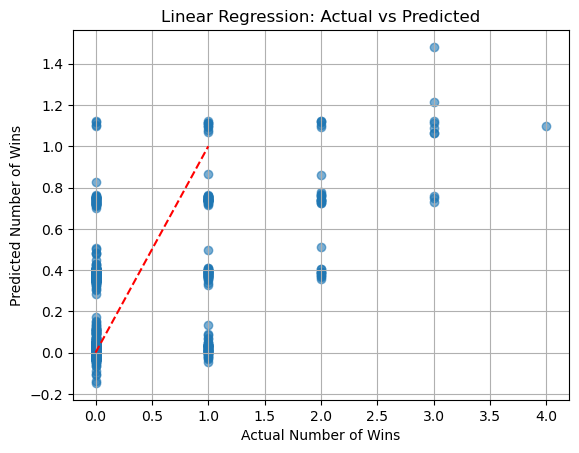

In [9]:
import matplotlib.pyplot as plt

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_train)

plt.scatter (y_train, y_pred_linear, alpha=0.6)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Linear Regression: Actual vs Predicted")
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.grid()
plt.show()

**Model 2: Ridge Regression**

Step 1: Cross-validation

In [10]:
#computing optimal alpha via cross-validation
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 50)  

ridge_pipeline = build_pipeline("ridge", RidgeCV(alphas=alphas, scoring='neg_mean_squared_error', cv=GroupKFold(n_splits=5)))


with config_context(enable_metadata_routing=True):

    cv_ridge = do_cv(
        ridge_pipeline,
        params={"groups": X_train["year"]},
        return_estimator=True,
    )

r2_ridge = cv_ridge['test_r2']
rmse_ridge = -cv_ridge['test_neg_root_mean_squared_error']


print(f"Best alphas: {[round(float(e.named_steps['ridge'].alpha_), 3) for e in cv_ridge['estimator']]}")
print(f"Cross-validated RMSE scores per fold: {-cv_ridge['test_neg_root_mean_squared_error']}")
print(f"Mean cross-validated RMSE: {-cv_ridge['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"Std Dev cross-validated RMSE: {cv_ridge['test_neg_root_mean_squared_error'].std():.4f}")
print(f"Cross-validated R² scores per fold: {cv_ridge['test_r2']}")
print(f"Mean cross-validated R²: {cv_ridge['test_r2'].mean():.4f}")
print(f"Std Dev cross-validated R²: {cv_ridge['test_r2'].std():.4f}")

Best alphas: [16.768, 11.514, 11.514, 24.421, 7.906]
Cross-validated RMSE scores per fold: [0.39214417 0.40040911 0.36942084 0.45696555 0.41177364]
Mean cross-validated RMSE: 0.4061
Std Dev cross-validated RMSE: 0.0290
Cross-validated R² scores per fold: [0.22059242 0.33608061 0.1647424  0.28852997 0.3176287 ]
Mean cross-validated R²: 0.2655
Std Dev cross-validated R²: 0.0639


Step 2: Plotting our results

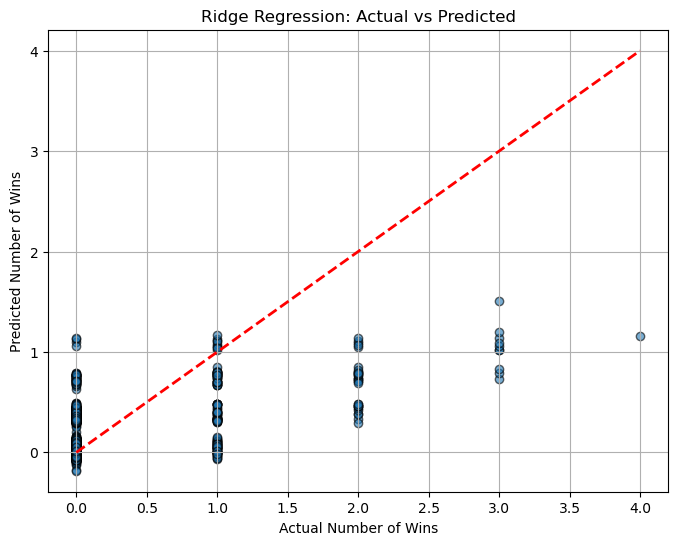

In [11]:
with config_context(enable_metadata_routing=True):
    ridge_pipeline.fit(X_train, y_train, groups=X_train["year"])

y_pred_ridge = ridge_pipeline.predict(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_ridge, alpha=0.6, edgecolor='k')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Ridge Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

Model 3: Lasso Regression

Step 1: Cross-validation

In [12]:
#computing optimal alpha via cross-validation

from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 4, 50)  

lasso_pipeline = build_pipeline("lasso", LassoCV(alphas=alphas, cv=GroupKFold(n_splits=5), random_state=42, max_iter=10000, fit_intercept=False))

with config_context(enable_metadata_routing=True):
    cv_lasso = do_cv(
        lasso_pipeline,
        params={"groups": X_train["year"]},
        return_estimator=True,
    )

r2_lasso = cv_lasso['test_r2']
rmse_lasso = -cv_lasso['test_neg_root_mean_squared_error']

print(f"Best alphas: {[round(float(e.named_steps['lasso'].alpha_), 3) for e in cv_lasso['estimator']]}")


print(f"Cross-validated RMSE scores per fold: {-cv_lasso['test_neg_root_mean_squared_error']}")
print(f"Mean cross-validated RMSE: {-cv_lasso['test_neg_root_mean_squared_error'].mean():.4f}")
print(f"Std Dev cross-validated RMSE: {cv_lasso['test_neg_root_mean_squared_error'].std():.4f}")
print(f"Cross-validated R² scores per fold: {cv_lasso['test_r2']}")
print(f"Mean cross-validated R²: {cv_lasso['test_r2'].mean():.4f}")
print(f"Std Dev cross-validated R²: {cv_lasso['test_r2'].std():.4f}")

Best alphas: [0.006, 0.004, 0.006, 0.009, 0.004]
Cross-validated RMSE scores per fold: [0.39646921 0.40254204 0.36933828 0.45845875 0.41280365]
Mean cross-validated RMSE: 0.4079
Std Dev cross-validated RMSE: 0.0291
Cross-validated R² scores per fold: [0.20330508 0.32898854 0.16511571 0.28387273 0.31421068]
Mean cross-validated R²: 0.2591
Std Dev cross-validated R²: 0.0640


Step 2: Plotting our results

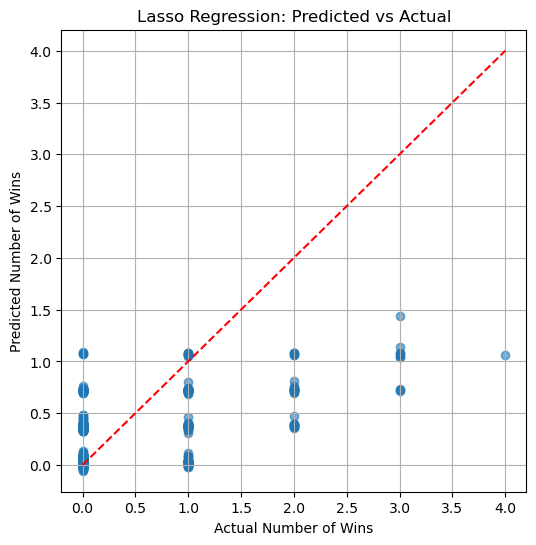

In [13]:
with config_context(enable_metadata_routing=True):
    lasso_pipeline.fit(X_train, y_train, groups=X_train["year"])

y_pred_lasso = lasso_pipeline.predict(X_train)

plt.figure(figsize=(6,6))
plt.scatter(y_train, y_pred_lasso, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  

plt.xlabel("Actual Number of Wins")
plt.ylabel("Predicted Number of Wins")
plt.title("Lasso Regression: Predicted vs Actual")
plt.grid(True)
plt.show()


**Model 4: Naive model**

Step 1: Running our model and computing RMSE and R^2 score

In [16]:
from models.naive import naive_win_counts
from sklearn.metrics import r2_score, root_mean_squared_error

n_baseline = 1000

rmse_naive = np.zeros(n_baseline)
r2_naive = np.zeros(n_baseline)

for i in range(n_baseline):
    naive_wins = naive_win_counts(df_train)
    rmse_naive[i] = root_mean_squared_error(y_train, naive_wins)
    r2_naive[i] = r2_score(y_train, naive_wins)

print(f"Naive model RMSE: {rmse_naive.mean():.4f}")
print(f"Naive model R² score: {r2_naive.mean():.4f}")
print(f"Naive model RMSE std: {rmse_naive.std():.4f}")
print(f"Naive model R² std: {r2_naive.std():.4f}")

Naive model RMSE: 0.6258
Naive model R² score: -0.7101
Naive model RMSE std: 0.0095
Naive model R² std: 0.0519


**Comparing models**

In [17]:
performance = pd.DataFrame({
    "Model": ["Naive", "Linear", "Ridge", "Lasso"],
    "R2": [r2_naive.mean(), r2_linear.mean(), r2_ridge.mean(), r2_lasso.mean()],
    "RMSE": [rmse_naive.mean(), rmse_linear.mean(), rmse_ridge.mean(), rmse_lasso.mean()],
    "R2_std": [r2_naive.std(), r2_linear.std(), r2_ridge.std(), r2_lasso.std()],
    "RMSE_std": [rmse_naive.std(), rmse_linear.std(), rmse_ridge.std(), rmse_lasso.std()],
})


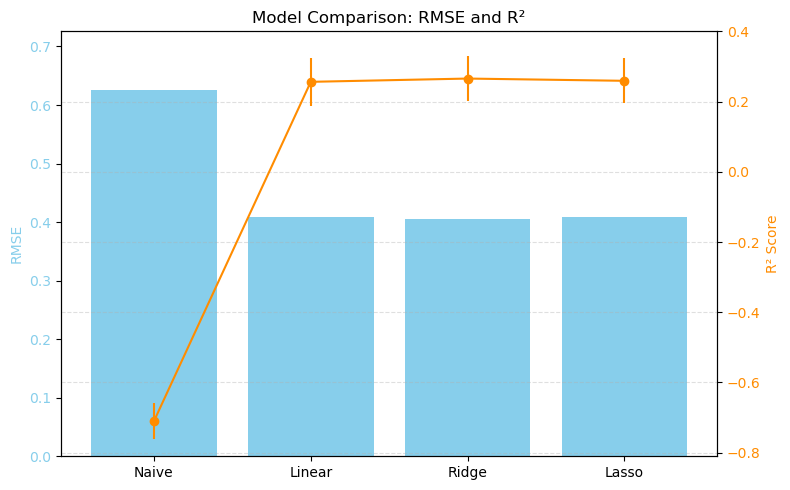

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# bar plot for RMSE
ax1.bar(performance["Model"], performance["RMSE"], color="skyblue", label="RMSE")
ax1.set_ylabel("RMSE", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")
ax1.set_ylim(0, max(performance["RMSE"]) + 0.1)

# create a second y-axis for R²
ax2 = ax1.twinx()
ax2.errorbar(performance["Model"], performance["R2"], color="darkorange", marker="o", label="R²", yerr=performance["R2_std"])
ax2.set_ylabel("R² Score", color="darkorange")
ax2.tick_params(axis='y', labelcolor="darkorange")
ax2.set_ylim(min(performance["R2"]) - 0.1, 0.4)

plt.title("Model Comparison: RMSE and R²")
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()
